<a href="https://colab.research.google.com/github/kojeda603/analisis_exploratorio_de_datos/blob/main/7_parcial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
pip install gapminder

In [34]:
from gapminder import gapminder

In [35]:
gapminder_1982 = gapminder[gapminder['year'] == 1982]
gapminder_1982.head(20)

,country,continent,year,lifeExp,pop,gdpPercap
6,Afghanistan,Asia,1982,39.854,12881816,978.011439
18,Albania,Europe,1982,70.420,2780097,3630.880722
30,Algeria,Africa,1982,61.368,20033753,5745.160213
42,Angola,Africa,1982,39.942,7016384,2756.953672
54,Argentina,Americas,1982,69.942,29341374,8997.897412
66,Australia,Oceania,1982,74.740,15184200,19477.009280
78,Austria,Europe,1982,73.180,7574613,21597.083620
90,Bahrain,Asia,1982,69.052,377967,19211.147310
102,Bangladesh,Asia,1982,50.009,93074406,676.981866
114,Belgium,Europe,1982,73.930,9856303,20979.845890


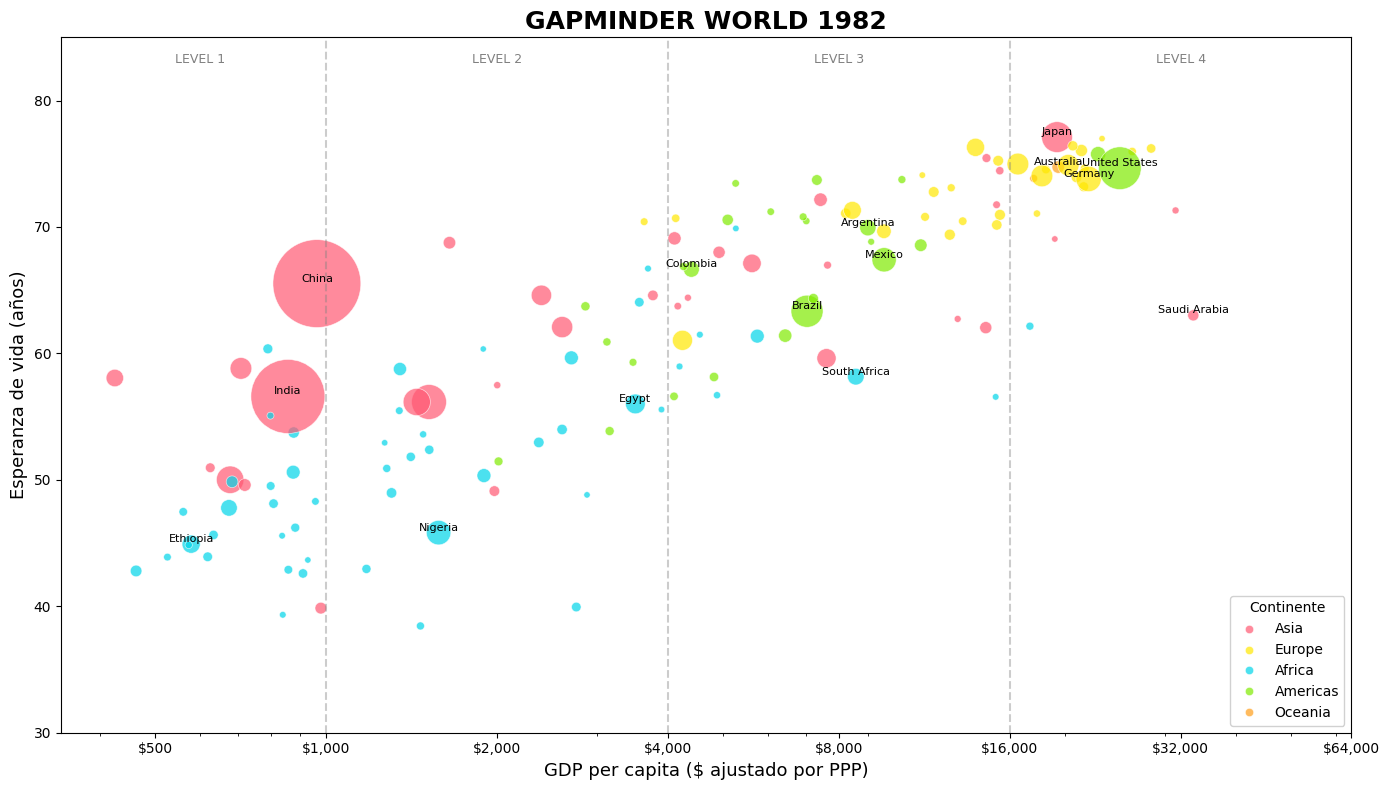

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Paleta de colores por continente
palette = {
    'Asia': '#FF5872',
    'Europe': '#FFE700',
    'Africa': '#00D5E9',
    'Americas': '#7FEB00',
    'Oceania': '#FF9F1A'
}

fig, ax = plt.subplots(figsize=(14, 8))

# Bubble chart
sns.scatterplot(
    data=gapminder_1982,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    hue='continent',
    palette=palette,
    sizes=(20, 4000),
    alpha=0.7,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

# Escala logarítmica en eje X (como el original)
ax.set_xscale('log')

# Etiquetas y formato
ax.set_xlabel('GDP per capita ($ ajustado por PPP)', fontsize=13)
ax.set_ylabel('Esperanza de vida (años)', fontsize=13)
ax.set_title('GAPMINDER WORLD 1982', fontsize=18, fontweight='bold')

#rango de los ejes
def formato_dolar(x, _):
    return f'${x:,.0f}'

ax.set_xticks([500, 1000, 2000, 4000, 8000, 16000, 32000, 64000])
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(formato_dolar))

# Rango del eje Y
ax.set_ylim(30, 85)

# Leyenda: ajustar para que no tape el gráfico
handles, labels = ax.get_legend_handles_labels()
# Separar leyenda de continente y de tamaño
ax.legend(
    handles=handles[1:6],
    labels=labels[1:6],
    loc='lower right',
    title='Continente',
    fontsize=10,
    framealpha=0.9
)

# Etiquetar países grandes o relevantes
paises_label = [    'Colombia', 'China', 'India', 'United States', 'Brazil', 'Japan',
    'Nigeria', 'Mexico', 'Germany', 'South Africa', 'Egypt',
    'Argentina', 'Australia', 'Ethiopia', 'Saudi Arabia']

for _, row in gapminder_1982[gapminder_1982['country'].isin(paises_label)].iterrows():
    ax.annotate(row['country'], (row['gdpPercap'], row['lifeExp']),
                fontsize=8, ha='center', va='bottom')

#separacion por niveles
niveles = [1000, 4000, 16000]
posiciones = [600, 2000, 8000, 32000]

for x in niveles:
    ax.axvline(x, color='gray', linestyle='--', alpha=0.4)

for i, pos in enumerate(posiciones):
    ax.text(pos, 83, f'LEVEL {i+1}', ha='center', fontsize=9, color='gray')


plt.tight_layout()
plt.show()

